# Apple Stock Price Prediction for Next 30 Days

## 1. Exploratory Data Analysis(EDA)

### Importing necessary libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

### Loading dataset

In [88]:
df = pd.read_csv("P639 DATASET.csv")

In [89]:
df.shape

(2011, 7)

In [90]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+ KB


### Convert Date column to datetime

In [92]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [93]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


### Checking for missing values

In [94]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

## Feature Engineering

In [95]:
df['MA_7'] = df['Adj Close'].rolling(window=7).mean()
df['MA_21'] = df['Adj Close'].rolling(window=21).mean()
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()

In [96]:
df['Volatility_7'] = df['Adj Close'].rolling(window=7).std()
df['Volatility_21'] = df['Adj Close'].rolling(window=21).std()

In [97]:
df['Daily_Return'] = df['Adj Close'].pct_change()

In [98]:
df['Market_Trend'] = df['Adj Close'].rolling(window=30).mean()

In [99]:
df.dropna(inplace=True)

### Normalization

In [100]:
scaler = MinMaxScaler()
scaled_cols = [
    'Open', 'High', 'Low', 'Adj Close', 'Volume',
    'MA_7', 'MA_21', 'MA_50',
    'Volatility_7', 'Volatility_21',
    'Daily_Return', 'Market_Trend'
]

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA_7,MA_21,MA_50,Volatility_7,Volatility_21,Daily_Return,Market_Trend
Date,,,,,,,,,,,,,
2012-03-14,0.115209,0.117670,0.116624,84.225716,0.099172,0.970321,0.076485,0.059615,0.024822,0.277279,0.158427,0.760101,0.048231
2012-03-15,0.128277,0.120861,0.118554,83.651428,0.097109,0.787245,0.080663,0.061639,0.026893,0.294346,0.177727,0.549881,0.050681
2012-03-16,0.119252,0.114342,0.118217,83.652855,0.097114,0.551107,0.084809,0.063978,0.028938,0.265214,0.184186,0.582080,0.053151
2012-03-19,0.127525,0.121922,0.124989,85.871429,0.105083,0.604624,0.089275,0.066609,0.031112,0.268420,0.199944,0.706922,0.055830
2012-03-20,0.128216,0.125016,0.126479,86.565712,0.107576,0.544872,0.093868,0.069372,0.033293,0.238486,0.211714,0.620083,0.058518


### Visualization

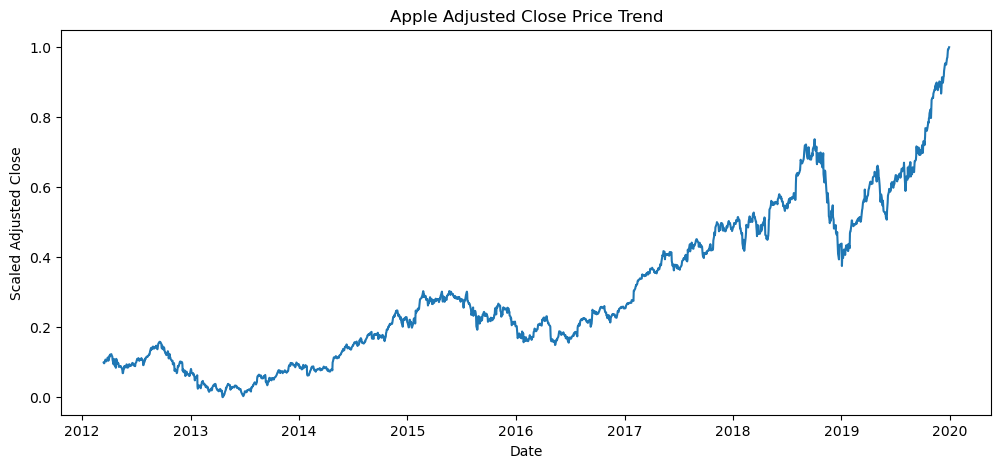

In [101]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Adj Close'])
plt.title("Apple Adjusted Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Scaled Adjusted Close")
plt.show()

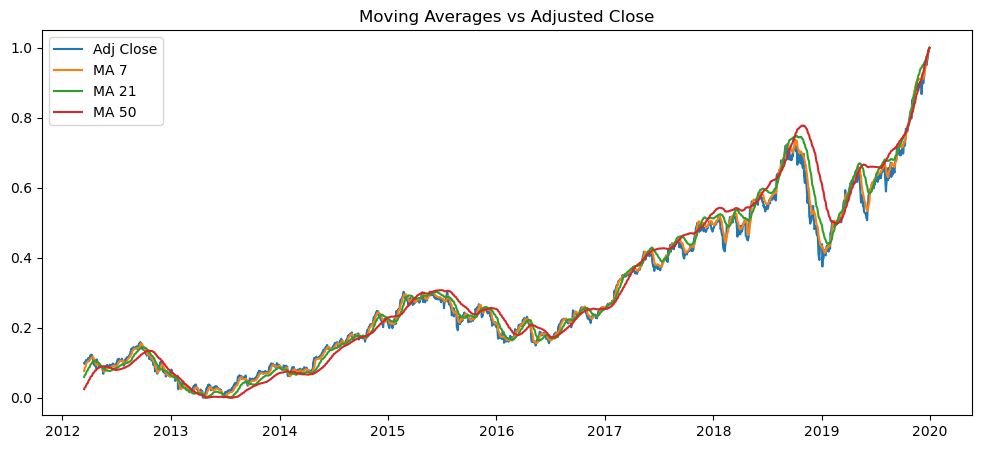

In [102]:
plt.figure(figsize=(12,5))
plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA_7'], label='MA 7')
plt.plot(df['MA_21'], label='MA 21')
plt.plot(df['MA_50'], label='MA 50')
plt.legend()
plt.title("Moving Averages vs Adjusted Close")
plt.show()

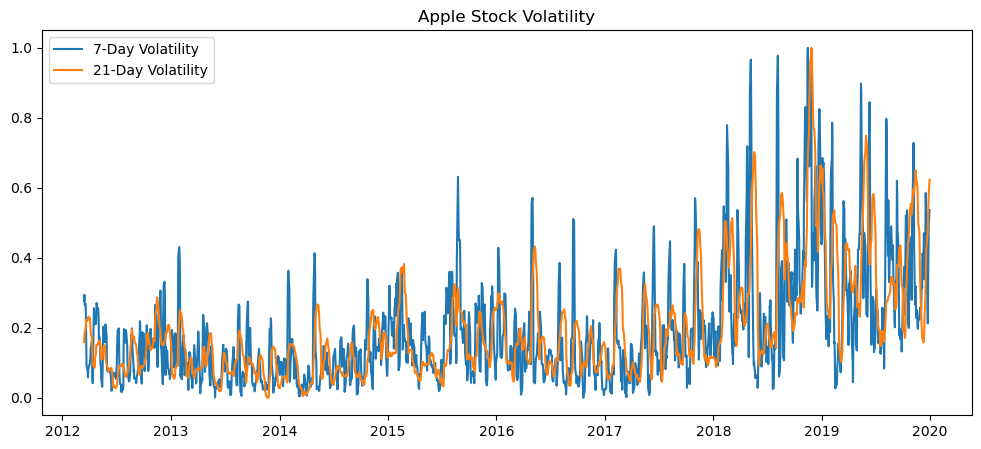

In [103]:
plt.figure(figsize=(12,5))
plt.plot(df['Volatility_7'], label='7-Day Volatility')
plt.plot(df['Volatility_21'], label='21-Day Volatility')
plt.legend()
plt.title("Apple Stock Volatility")
plt.show()

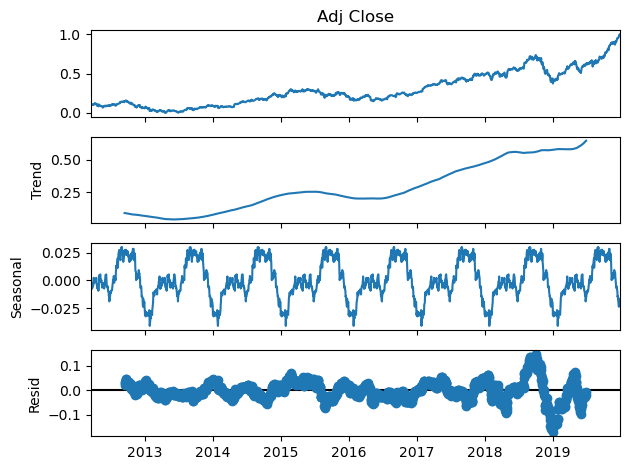

In [104]:
decomposition = seasonal_decompose(df['Adj Close'], model='additive', period=252)
decomposition.plot()
plt.show()

## ADF Test

In [105]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Adj Close'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: 1.682928321198487
p-value: 0.9980862181159331
Critical Value (1%): -3.433704467332038
Critical Value (5%): -2.8630218030562116
Critical Value (10%): -2.5675588519656176


#### The p-value is greater than 0.05 hence the data is non-stationary.

### Making data stationary

In [106]:
df['Adj_Close_Diff'] = df['Adj Close'].diff()
df_stationary = df.dropna()

#### The trend is removed to have series as stationary.

### Checking the data again

In [107]:
adf_result_diff = adfuller(df_stationary['Adj_Close_Diff'])
print("ADF Statistic:", f"{adf_result_diff[0]:.6f}")
print("p-value:", f"{adf_result_diff[1]:.6f}")

ADF Statistic: -13.321192
p-value: 0.000000


### Train-Test Split

In [108]:
train = df_stationary[:-30]
test = df_stationary[-30:]

## Model Selection and Building

### ARIMA Model

In [109]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
arima_model = ARIMA(train['Adj_Close_Diff'], order=(1,1,1))
arima_fit = arima_model.fit()
forecast_diff = arima_fit.forecast(steps=len(test))
last_value = df['Adj Close'].iloc[-31]
forecast_arima = last_value + forecast_diff.cumsum()
forecast_arima = pd.Series(forecast_arima.values, index=df.index[-30:])

In [110]:
rmse_arima = math.sqrt(mean_squared_error(test['Adj Close'], forecast_arima))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 0.041247947896732556


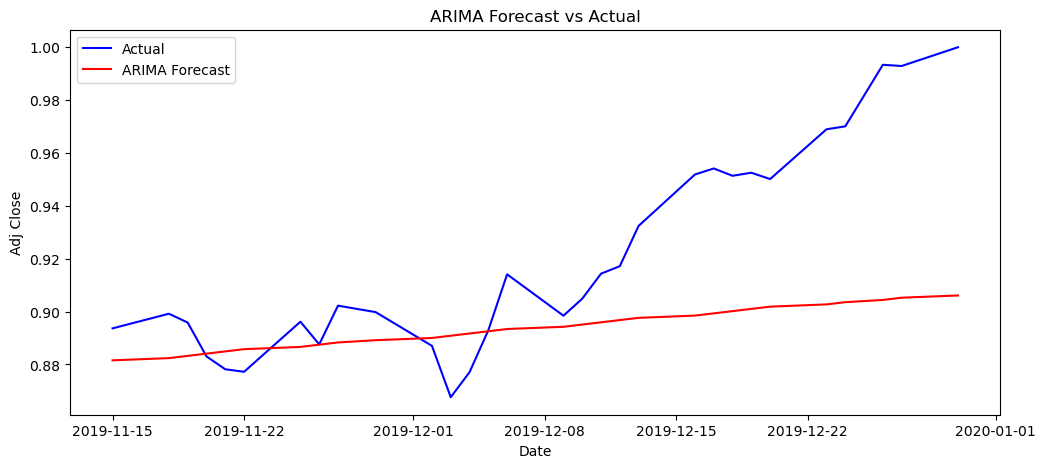

In [111]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Adj Close'], label='Actual', color='blue')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='red')
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.legend()
plt.show()

#### The arima forecast shows underlying trend of data series indicating uptrend.

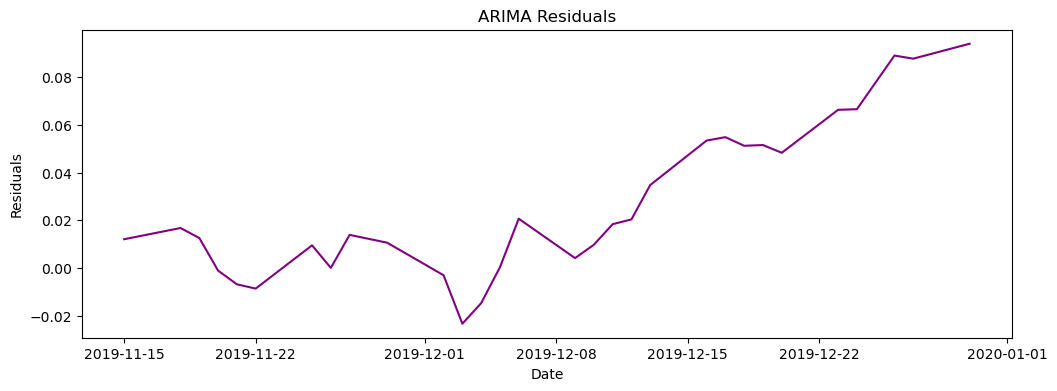

In [112]:
residuals_arima = df['Adj Close'].iloc[-30:] - forecast_arima
plt.figure(figsize=(12,4))
plt.plot(df.index[-30:], residuals_arima, color='purple')
plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

#### ARIMA residuals show that the model captures trend but misses rapid fluctuations, highlighting its limitation in volatile markets.

### ARIMAX Model

In [113]:
exog_features = [
    'MA_7','MA_21','MA_50',
    'Volatility_7','Volatility_21',
    'Market_Trend'
]

arimax_model = ARIMA(
    train['Adj Close'],
    order=(5,1,0),
    exog=train[exog_features]
)

arimax_fit = arimax_model.fit()
forecast_arimax = arimax_fit.forecast(
    steps=30,
    exog=test[exog_features]
)
forecast_arimax = pd.Series(forecast_arimax.values, index=test.index)

In [114]:
rmse_arimax = math.sqrt(mean_squared_error(test['Adj Close'], forecast_arimax))
print("ARIMAX RMSE:", rmse_arimax)

ARIMAX RMSE: 0.017571650866937173


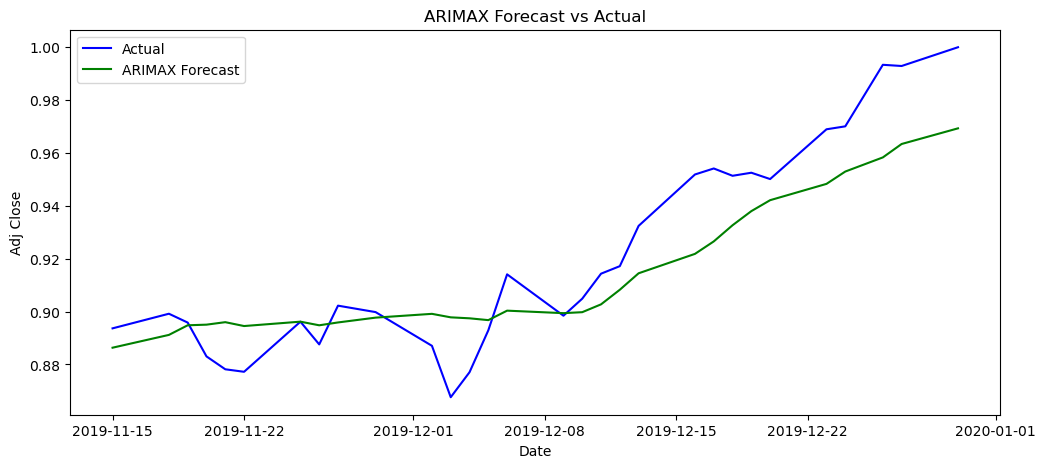

In [115]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Adj Close'], label='Actual', color='blue')
plt.plot(test.index, forecast_arimax, label='ARIMAX Forecast', color='green')
plt.title("ARIMAX Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.legend()
plt.show()

#### The ARIMAX forecast follows the actual price movements more closely, capturing both the overall trend and short-term fluctuations due to the inclusion of exogenous market indicators.

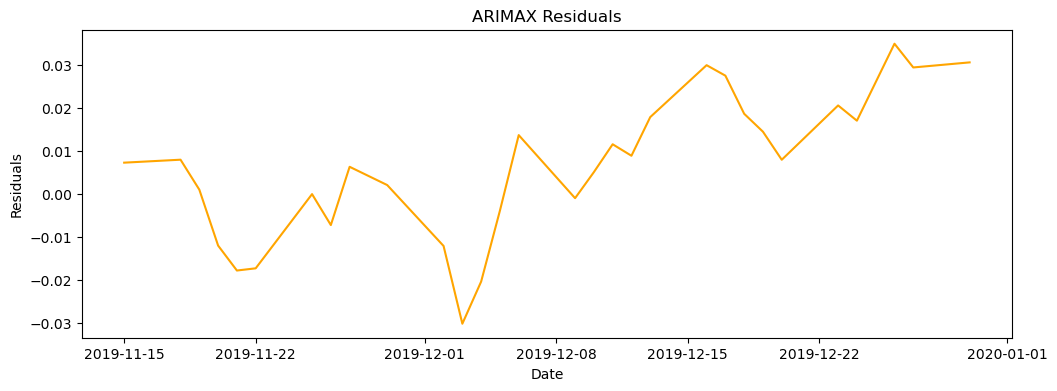

In [116]:
residuals_arimax = test['Adj Close'] - forecast_arimax
plt.figure(figsize=(12,4))
plt.plot(test.index, residuals_arimax, color='orange')
plt.title("ARIMAX Residuals")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

#### ARIMAX residuals still resemble the actual price fluctuations due to inherent market volatility, but the model reduces overall error and better captures short-term movements than ARIMA.

### SARIMA Model

In [117]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(
    train['Adj Close'],
    order=(1,1,1),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)
forecast_sarima = sarima_fit.forecast(steps=len(test))
forecast_sarima = pd.Series(forecast_sarima.values, index=df.index[-30:])

In [118]:
rmse_sarima = np.sqrt(mean_squared_error(test['Adj Close'], forecast_sarima))
print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 0.053912702102322685


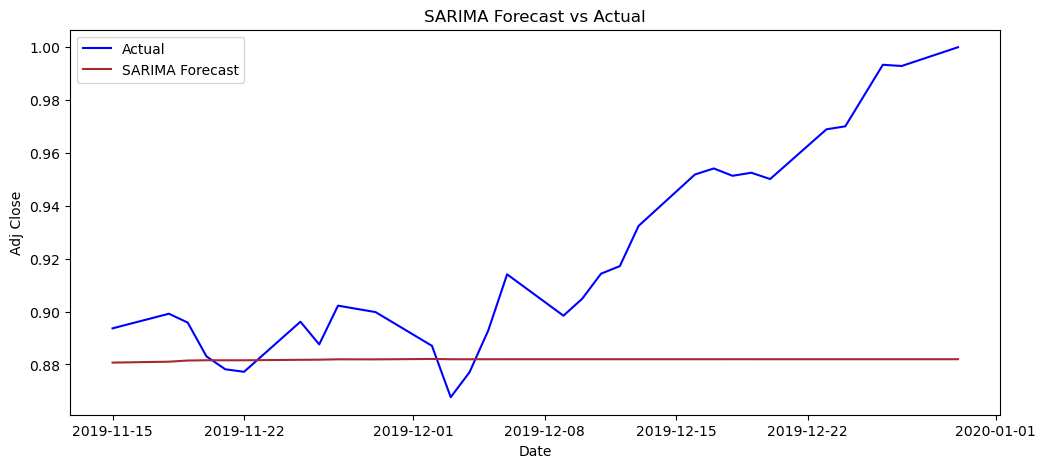

In [119]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Adj Close'], label='Actual', color='blue')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast', color='brown')
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.legend()
plt.show()

#### SARIMA is better suited for series with strong seasonal effects; here, short-term volatility dominates, so the forecast appears flat.

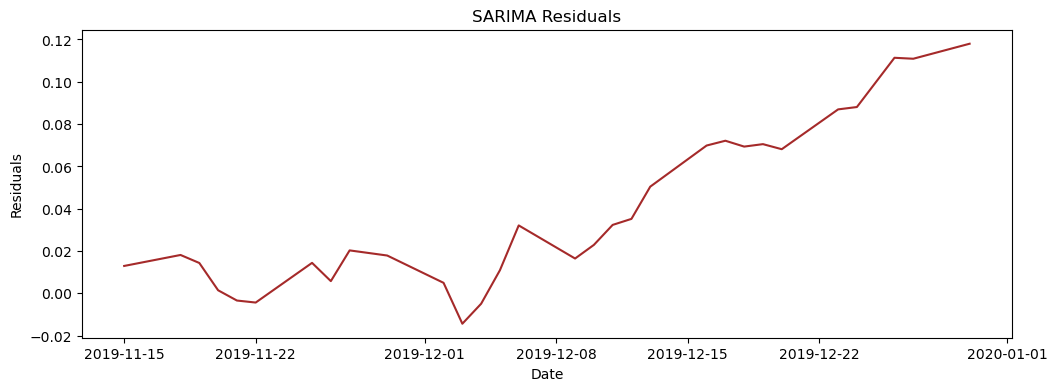

In [120]:
residuals_sarima = test['Adj Close'] - forecast_sarima
plt.figure(figsize=(12,4))
plt.plot(test.index, residuals_sarima, color='brown')
plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

#### SARIMA shows higher residuals due to its flat forecast

### Prophet Model

In [121]:
from prophet import Prophet
prophet_df = df.reset_index()[['Date', 'Adj Close']]
prophet_df.columns = ['ds', 'y']

#### Prophet requires this column format to internally handle datetime features and model yearly, weekly, and daily seasonality if present.

In [122]:
n = len(prophet_df)
train_size = int(n * 0.8)
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [123]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model.fit(train_prophet)

22:15:01 - cmdstanpy - INFO - Chain [1] start processing
22:15:01 - cmdstanpy - INFO - Chain [1] done processing


In [124]:
future = model.make_future_dataframe(periods=len(test_prophet))
forecast = model.predict(future)
pred_prophet = forecast['yhat'][-len(test_prophet):].values

In [125]:
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], pred_prophet))
print("Prophet RMSE:", rmse_prophet)

Prophet RMSE: 0.10857039630774579


#### Prophet excels in detecting trend and seasonal patterns, but for volatile daily stock prices, short-term accuracy is lower compared to ARIMAX, which uses external indicators.

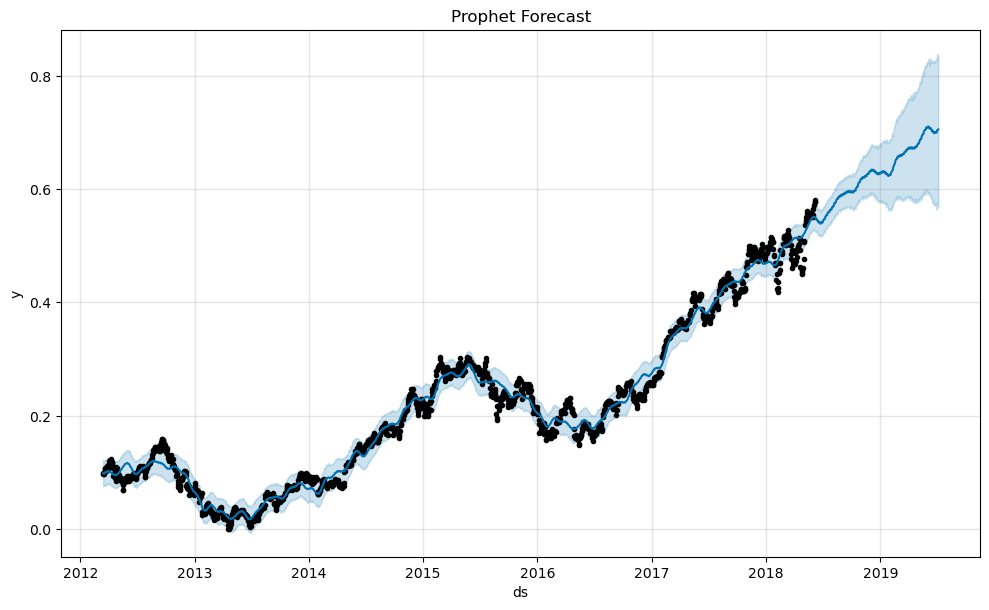

In [126]:
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

#### The Prophet forecast line closely follows historical data (black dots) during training, then continues as a smooth prediction for future dates, capturing trend and seasonality while ignoring short-term fluctuations.

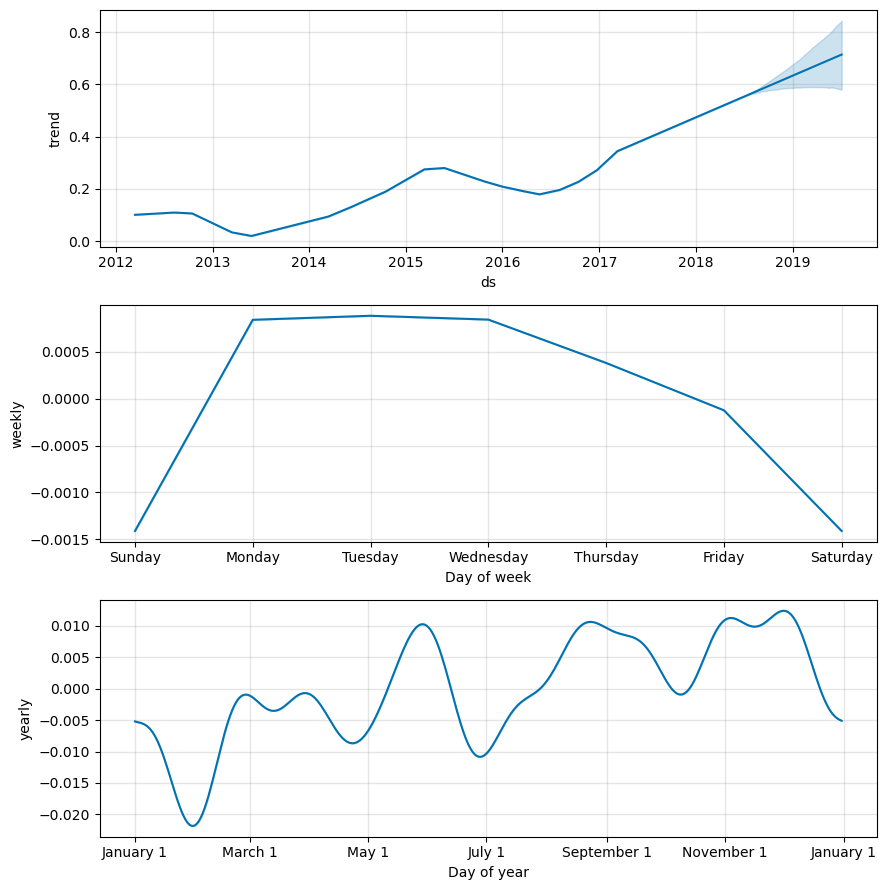

In [127]:
model.plot_components(forecast)
plt.show()

#### The components plot shows that Prophet decomposes stock prices into a dominant trend, plus minor weekly and yearly seasonal effects, explaining the smooth forecast line

### Lag Feature 

In [128]:
for i in range(1,8):
    df[f'lag_{i}'] = df['Adj Close'].shift(i)
df_ml = df.dropna()

In [129]:
ml_features = [
    'MA_7','MA_21','MA_50',
    'Volatility_7','Volatility_21',
    'Market_Trend','Daily_Return'
] + [f'lag_{i}' for i in range(1,8)]

X = df_ml[ml_features]
y = df_ml['Adj Close']
X_train = X[:-30]
X_test = X[-30:]
y_train = y[:-30]
y_test = y[-30:]

### Gradient Boosting

In [130]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))
print("GBR RMSE:", rmse_gbr)

GBR RMSE: 0.05600771162022585


#### GBR captures non-linear relationships between past prices, technical indicators, and future price.
#### It reduces error compared to models that only use trend or seasonality, but may not perfectly capture very short-term volatility spikes.

### Random Forest

In [131]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = math.sqrt(mean_squared_error(y_test, pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 0.05651959156303561


####  It captures non-linear relationships but may not perfectly track sharp short-term fluctuations

### XGBoost Model

In [132]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
rmse_xgb = math.sqrt(mean_squared_error(y_test, pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.08901615019531862


#### XGBoost performs better than Prophet but worse than ARIMAX, GBR, and ARIMA for this short-term stock prediction.
#### Likely affected by small dataset size for short-term testing

### Support Vector Regression

In [133]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train, y_train)
pred_svr = svr.predict(X_test)
rmse_svr = math.sqrt(mean_squared_error(y_test, pred_svr))
print("SVR RMSE:", rmse_svr)

SVR RMSE: 0.1230876492287752


#### SVR performed worst among all models for short-term stock price prediction in this dataset.
#### It captures non-linear relationships, but is less effective with high volatility and small test sets.

### Model Evaluation Before Tuning

In [134]:
stat_models = ['ARIMA', 'SARIMA', 'ARIMAX', 'Prophet']
stat_rmse = [rmse_arima, rmse_sarima, rmse_arimax, rmse_prophet]
ml_models = ['Gradient Boosting', 'Random Forest', 'XGBoost', 'SVR']
ml_rmse = [rmse_gbr, rmse_rf, rmse_xgb, rmse_svr]
stat_rmse = [float(f"{x:.3f}") for x in stat_rmse]
ml_rmse = [float(f"{x:.3f}") for x in ml_rmse]
results_df = pd.DataFrame({
    'Statistical Models': stat_models,
    'Statistical RMSE': stat_rmse,
    'ML Models': ml_models,
    'ML RMSE': ml_rmse
})
print(results_df)

  Statistical Models  Statistical RMSE          ML Models  ML RMSE
0              ARIMA             0.041  Gradient Boosting    0.056
1             SARIMA             0.054      Random Forest    0.057
2             ARIMAX             0.018            XGBoost    0.089
3            Prophet             0.109                SVR    0.123


### Hyperparameter Tuning

#### Gradient Boosting Model Tuning

In [135]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [300,400],
    'max_depth': [1,2],
    'learning_rate': [ 0.1,0.50],
    'subsample': [1.0,1.2]
}
gbr = GradientBoostingRegressor(random_state=42)
grid_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid, 
                        cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_gbr.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.5], 'max_depth': [1, 2],
                         'n_estimators': [300, 400], 'subsample': [1.0, 1.2]},
             scoring='neg_mean_squared_error', verbose=2)

In [136]:
print("Best parameters for GBR:", grid_gbr.best_params_)
pred_gbr = grid_gbr.best_estimator_.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))
print("Tuned Gradient Boosting RMSE:", rmse_gbr)

Best parameters for GBR: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 400, 'subsample': 1.0}
Tuned Gradient Boosting RMSE: 0.05674105819443302


#### Random Forest Model Tuning

In [137]:
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'n_estimators': [300,400],
    'max_depth': [15,20],
    'min_samples_split': [1,2],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                       cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [15, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [1, 2],
                         'n_estimators': [300, 400]},
             scoring='neg_mean_squared_error', verbose=2)

In [138]:
print("Best parameters for RF:", grid_rf.best_params_)
pred_rf = grid_rf.best_estimator_.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print("Tuned Random Forest RMSE:", rmse_rf)

Best parameters for RF: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Tuned Random Forest RMSE: 0.058357423576293074


#### XGBoost Model Tuning

In [139]:
from xgboost import XGBRegressor
param_grid = {
    'n_estimators': [700,800],
    'max_depth': [2, 3],
    'learning_rate': [0.05, 0.1],
    'subsample': [1.0, 1.2]
}
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid,
                        cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [2, 3],
                         'n_estimators': [700, 800], 'subsample': [1.0, 1.2]},
             scoring='neg_mean_squared_error', verbose=2)

In [140]:
print("Best parameters for XGBoost:", grid_xgb.best_params_)
pred_xgb = grid_xgb.best_estimator_.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print("Tuned XGBoost RMSE:", rmse_xgb)

Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'subsample': 1.0}
Tuned XGBoost RMSE: 0.06920304791224569


#### SVR Model Tuning

In [141]:
from sklearn.svm import SVR
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 5, 50],
    'gamma': ['scale', 'auto']
}
svr = SVR()
grid_svr = GridSearchCV(estimator=svr, param_grid=param_grid,
                        cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_svr.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 5, 50], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             scoring='neg_mean_squared_error', verbose=2)

In [142]:
print("Best parameters for SVR:", grid_svr.best_params_)
pred_svr = grid_svr.best_estimator_.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test, pred_svr))
print("Tuned SVR RMSE:", rmse_svr)

Best parameters for SVR: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Tuned SVR RMSE: 0.09768009679318236


### Model Evaluation After Tuning

In [143]:
stat_models = ['ARIMA', 'SARIMA', 'ARIMAX', 'Prophet']
stat_rmse = [rmse_arima, rmse_sarima, rmse_arimax, rmse_prophet]
ml_models = ['Gradient Boosting', 'Random Forest', 'XGBoost', 'SVR']
ml_rmse = [rmse_gbr, rmse_rf, rmse_xgb, rmse_svr]
stat_rmse = [float(f"{x:.3f}") for x in stat_rmse]
ml_rmse = [float(f"{x:.3f}") for x in ml_rmse]
results_df = pd.DataFrame({
    'Statistical Models': stat_models,
    'Statistical RMSE': stat_rmse,
    'ML Models': ml_models,
    'ML RMSE': ml_rmse
})
print(results_df)

  Statistical Models  Statistical RMSE          ML Models  ML RMSE
0              ARIMA             0.041  Gradient Boosting    0.057
1             SARIMA             0.054      Random Forest    0.058
2             ARIMAX             0.018            XGBoost    0.069
3            Prophet             0.109                SVR    0.098


##### The purpose of training both statistical and machine learning models was to objectively compare their forecasting capabilities on the same dataset. This allowed me to identify that ARIMAX, a statistical model, was more suitable than ML models for short-term Apple stock price prediction

## ARIMAX Training

In [144]:
import pandas as pd
import numpy as np
import joblib
import pickle
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler

In [145]:
df = pd.read_csv("P639 DATASET.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df['MA_7'] = df['Adj Close'].rolling(window=7).mean()
df['MA_21'] = df['Adj Close'].rolling(window=21).mean()
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()
df['Volatility_7'] = df['Adj Close'].rolling(window=7).std()
df['Volatility_21'] = df['Adj Close'].rolling(window=21).std()
df['Daily_Return'] = df['Adj Close'].pct_change()
df['Market_Trend'] = df['Adj Close'].rolling(window=30).mean()
df.dropna(inplace=True)

#### Even though features were created at the start, redoing them in each section ensures consistency, reproducibility, and modular code

In [146]:
adj_scaler = MinMaxScaler()
df['Adj_Close_scaled'] = adj_scaler.fit_transform(df[['Adj Close']])
joblib.dump(adj_scaler, "adj_scaler.pkl")
# Exogenous features
exog_features = ['MA_7','MA_21','Volatility_7','Market_Trend']
exog_scaler = MinMaxScaler()
df[exog_features] = exog_scaler.fit_transform(df[exog_features])
joblib.dump(exog_scaler, "exog_scaler.pkl")

['exog_scaler.pkl']

In [147]:
y = df['Adj_Close_scaled']
X = df[exog_features]

In [148]:
arimax_model = SARIMAX(
    y,
    exog=X,
    order=(5,1,0),   
    enforce_stationarity=False,
    enforce_invertibility=False
)
arimax_result = arimax_model.fit()
print(arimax_result.summary())

                               SARIMAX Results                                
Dep. Variable:       Adj_Close_scaled   No. Observations:                 1962
Model:               SARIMAX(5, 1, 0)   Log Likelihood                6756.045
Date:                Wed, 11 Feb 2026   AIC                         -13492.091
Time:                        22:16:17   BIC                         -13436.304
Sample:                             0   HQIC                        -13471.584
                               - 1962                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
MA_7             0.9671      0.042     23.142      0.000       0.885       1.049
MA_21            0.1773      0.106      1.675      0.094      -0.030       0.385
Volatility_7     0.0045      0.001      3.20

#### Residuals are largely uncorrelated, indicating the model captures most patterns. Some non-normality and heteroskedasticity remain, which is typical for stock prices
#### Most features are statistically significant.
#### ARIMAX leverages both autoregressive behavior and external predictors, achieving low residual variance and statistically significant coefficients, making it ideal for forecasting volatile stock prices.

In [149]:
forecast_horizon = 30
last_exog = X.iloc[-1]
future_exog = pd.DataFrame(
    [last_exog.values] * forecast_horizon,
    columns=exog_features
)

#### For short-term prediction, we replicate the last observed values of all exogenous features as future inputs, allowing the ARIMAX model to forecast the next month.

In [150]:
forecast = arimax_result.get_forecast(
    steps=forecast_horizon,
    exog=future_exog
)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

forecast_df = pd.DataFrame({
    'Forecast': forecast_mean,
    'Lower CI': forecast_ci.iloc[:, 0],
    'Upper CI': forecast_ci.iloc[:, 1]
})
forecast_df.head()

,Forecast,Lower CI,Upper CI
1962,0.997297,0.982314,1.012279
1963,0.997133,0.976733,1.017534
1964,0.995742,0.972191,1.019294
1965,0.997061,0.971441,1.022681
1966,0.997401,0.970190,1.024612


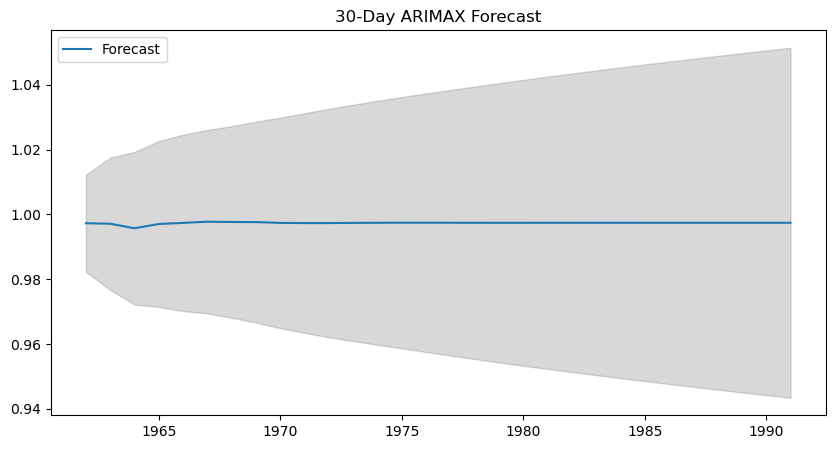

In [151]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(forecast_df['Forecast'], label='Forecast')
plt.fill_between(
    forecast_df.index,
    forecast_df['Lower CI'],
    forecast_df['Upper CI'],
    color='gray',
    alpha=0.3
)
plt.title("30-Day ARIMAX Forecast")
plt.legend()
plt.show()

#### The forecast line represents predicted prices, while the shaded confidence interval quantifies uncertainty. This visual helps to understand both the expected trend and the range of possible outcomes.

In [152]:
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
n_steps = len(forecast_mean)
inv_df = pd.DataFrame(
    np.zeros((n_steps, len(scaled_cols))),
    columns=scaled_cols
)
inv_df['Adj Close'] = forecast_mean.values

In [153]:
forecast_real = scaler.inverse_transform(inv_df)[:, scaled_cols.index('Adj Close')]

forecast_df = pd.DataFrame({
    'Forecast_Real_Price': forecast_real
})
forecast_df.head()

,Forecast_Real_Price
0,288.872166
1,288.832903
2,288.498227
3,288.815529
4,288.897277


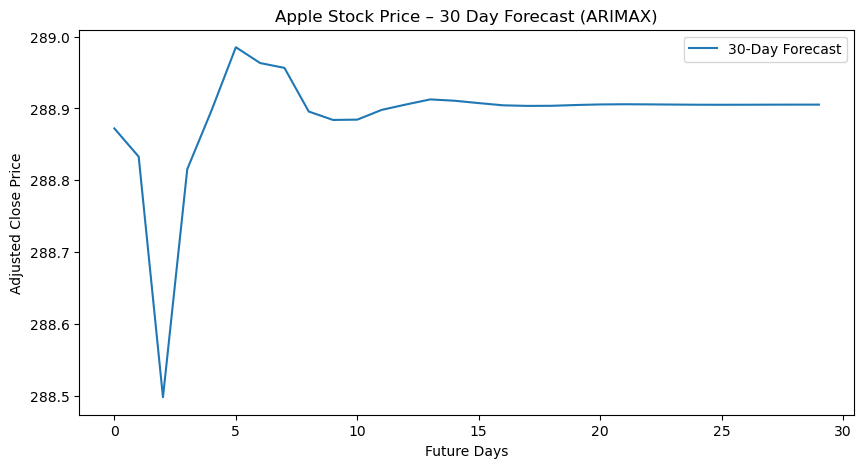

In [154]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(forecast_df['Forecast_Real_Price'], label='30-Day Forecast')
plt.title("Apple Stock Price – 30 Day Forecast (ARIMAX)")
plt.xlabel("Future Days")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()

# Deployment

In [155]:
import joblib
import statsmodels.api as sm
arimax_result.save("arimax_model.pkl")